# Re-Optimize Mini Neptune cases w/ Modern/Archean Earth

Description of Issue:

The code here removes all layers of the atmosphere that are T > 1000 K, in order to avoid that bug in the opacity database. This is not what I had imagined as a fix/hack. The problem with the current implementation is that it means that it effectively places a surface at the layer where T first exceeds 1000 K.

Instead, a better fix should not remove any layers from the atmosphere. Instead just change the temperature in those layers to no more than ~1000 K. 

The best solution is to use the new opacity databases here (https://zenodo.org/records/20397663), which can be used for T > 1000 K.

Which Unfortunately Was Used in the Following:
1. Finding Mini Neptune Reflected Light Spectra's that were a match to Archean Earth from the limited cases with similarly abundant molecules (dictionary of 5000+).
2. Finding Mini Neptune Reflected Light Spectra's that were a match to Modern Earth (dictionary of 175+).
3. Which means I will need to re-run code on all reported "optimal cases" of the following variety; top match to Archean Earth, top match to Modern Earth, and top match within the following filter range:
- metallicity: ~42 - 237x solar metallicity 
- tint: 50 - 100K
- semi-major: 0.7 - 1.5 AU

But first I should test the new code to see how different the reflected spectra grid is with this change - DONE! Turns out most of the differences are in shorter wavelengths (i.e. below 1 micron), where my optimization occured between [0.75, 2.5] which actually isn't terrible! Send updated file to Nick for his use.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const

import heapq

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as Photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path

current_directory = Path.cwd()
references_directory_path = "Installation_Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation_Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds


In [2]:
from cycler import cycler

def plot_reflected_spectrum_new(wno=None, alb=None, inputs=None, legend_label=None, ax1=None, fill_curves=None):
    """
    wno = list of wavenumbers to plot (can be [[],[]]...)
    alb = list of albedos associated with wavenumbers (can be [[],[]...])
    inputs = list of inputs associated with the wavenumbers and albedos (can be [[],[],...]); |
        note inputs should be ordered like radius, metallicity, internal temperature, 
        semi-major axis, c/o ratio, and kzz mixing coefficient.
    legend_label = list of strings describing what dataset you are pulling from
    fill_curves = a float; fills the last fill_curve value of curves|
    """
        
    # Define a list of colors or use a color cycle
    colors = ['green', 'red', 'black']

    if ax1 is None:
        fig, ax1 = plt.subplots(1,1,figsize=[10,4])

    for index in range(len(wno)):
        if inputs[index] is not None:
            print(f'{inputs[index][0]}_{inputs[index][1]}_{inputs[index][2]}_{inputs[index][3]}_{inputs[index][4]}_{inputs[index][5]}')
        else:
            print(f'Included Earth Plot that does not have inputs.')

        # Fill last two curves
        if fill_curves is not None:
            if index >= len(wno) - fill_curves:
                line, = ax1.plot(1e4/wno[index], alb[index], linestyle='--', lw=0.5, label=legend_label[index])
                ax1.fill_between(1e4/wno[index], alb[index], color=line.get_color(), alpha=0.15)
            else:
                ax1.plot(1e4/wno[index], alb[index], linestyle='-', lw=2, label=legend_label[index])

        else:
            ax1.plot(1e4/wno[index], alb[index], linestyle='-', lw=2, label=legend_label[index])
        
    ax1.set_prop_cycle(cycler(color=['red', 'green', 'blue', 'black']))

    ax1.set_xlim(0.2, 2)
    #ax1.set_ylim(0, 0.35)
    ax1.set_ylabel('Albedo')
    ax1.set_xlabel('Wavelength (microns)')

    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    if ax1 is None:
        plt.tight_layout()
        
        plt.show()

In [19]:
def get_top_molecules_for_case(photochem_data=None, top_n=15):

    excluded_suffixes = ('aer_sol', 'aer_soleq', 'soleq')
    excluded_exact = {
        'pressure_sol', 'temperature_sol', 'Kzz_sol',
        'pressure_soleq', 'temperature_soleq', 'Kzz_soleq',
        'converged_PC', 'converged_TP', 'temperature', 'pressure', 'Kzz'
    }
    
    molecule_means = {}

    # --- Load pressure profile for this case ---
    pressure = photochem_data['pressure']
    sol = photochem_data['sol_dict']

    # Pressure is high → low, so select where 0 < P < 10 bar
    valid = (pressure > 0) & (pressure < 10)
    print(valid)

    # If no valid region, skip this case
    if not np.any(valid):
        return [], {}

    for key in sol.keys():
        if key in excluded_exact:
            continue
        if key.endswith(excluded_suffixes):
            continue

        # Try to extract dataset
        try:
            dataset = sol[key]
        except Exception:
            continue

        # Skip non-numeric datasets
        if not np.issubdtype(dataset.dtype, np.number):
            continue

        # Slice dataset using the pressure mask
        sliced = dataset[valid]

        # Compute mean mixing ratio in the 0–10 bar region
        mean_val = np.nanmean(sliced)
        molecule_means[key] = mean_val

    # Get top N molecules
    top_keys = heapq.nlargest(top_n, molecule_means, key=molecule_means.get)

    return top_keys, molecule_means

In [48]:
def find_pbot(sol=None, solaer=None, tol=0.9):

    """
    Parameters:
    pressures: ndarray
        Pressure at each atmospheric layer in dynes/cm^2
    H2Oaer: ndarray
        Mixing ratio of H2O aerosols.
    tol: float, optional
        The threshold value for which we define the beginning of the cloud, 
        by default 1e-4. 

    Returns:
    P_bottom: float
        The cloud bottom pressure in dynes/cm^2
        
    """

    pressure = sol['pressure']
    H2Oaer = solaer['H2Oaer']

    # There is no water cloud in the model, so we return None
    # For the cloud bottom of pressure

    if np.max(H2Oaer) < 1e-20:
        return None

    # Normalize so that max value is 1
    H2Oaer_normalized = H2Oaer/np.max(H2Oaer)

    # loop from bottom to top of atmosphere, cloud bottom pressure
    # defined as the index level where the normalized cloud mixing ratio
    # exeeds tol .

    ind = None
    
    for i, val in enumerate(H2Oaer_normalized):
        if val > tol:
            ind = i
            break

    if ind is None:
        raise Exception('A problem happened when trying to find the bottom of the cloud.')

    # Bottom of the cloud
    pbot = pressure[ind]

    return pbot

def plot_photochem_model_with_cloud(sol=None, soleq=None, ax1=None, show_legend=True):

    """
    Parameters:
        TBD
    """
    solaer_dict = {}

    for key, value in sol.items():
        if key.endswith('aer'):
            solaer_dict[key] = value
            
    print(solaer_dict.keys())
        
    pbot = find_pbot(sol=sol, solaer=solaer_dict)
    
    # Plot the Composition from Photochem
    if ax1 is None:
        fig, ax1 = plt.subplots(1,1,figsize=[8,6])
        
    
    species = ['H2', 'He', 'H', 'CO', 'CO2', 'C2H2', 'CH4', 'N2', 'H2O', 'C4H2', 'C2H6', 'C2H4'] # What about CH4?
    species_aer = ['H2Oaer']

    custom_colors = ['red', 'green', 'magenta', 'orange', 'purple', 'grey', 'brown', 'black', 'blue', 'cyan', 'pink', 'limegreen']
    custom_colors_2 = ['skyblue']

    index_sol = 0
    index_soleq = 0
    
    for i,sp in enumerate(species):
        ax1.plot(sol[sp],np.array(sol['pressure'])/1e6, c=custom_colors[index_sol], label=sp)
        index_sol += 1

    for i, sp in enumerate(species_aer):
        ax1.plot(sol[sp], np.array(sol['pressure'])/1e6, c=custom_colors_2[index_soleq], label=sp)
        index_soleq += 1
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(1e-5,1)
    ax1.set_ylim(1000,1e-7)
    ax1.grid(alpha=0.4)
    ax1.set_xlabel('Mixing Ratio', fontsize=16)
    ax1.set_ylabel('Pressure (bars)', fontsize=16)
    ax1.set_yticks(10.0**np.arange(-6,2))
    ax1.tick_params(axis='x', labelsize=16) 
    ax1.tick_params(axis='y', labelsize=16)
    
    
    # Thickness of the box cloud
    ptop_earth = 0.6
    pbot_earth = 0.7
    logdp = np.log10(pbot_earth) - np.log10(ptop_earth)
    
    # Outline of the box cloud
    x_values = np.logspace(-8, 0, 10)
    y_values_bot = [pbot/10**6] * len(x_values)
    y_values_top = [((10**(np.log10(pbot/10**6) - logdp)))] * len(x_values)
    
    ax1.plot(x_values, y_values_bot, c='black', ls='--')
    ax1.plot(x_values, y_values_top, c='black', ls='--')

    print(y_values_bot[0], y_values_top[0])

    # Quickly add check to what RLS reported as top of cloud and bottom of cloud
    ax1.plot(x_values, [0.0299] * len(x_values), color='red', alpha=0.2, label='RLS reported top cloud')
    ax1.plot(x_values, [0.0404] * len(x_values), color='orange', alpha=0.2, label='RLS reported bottom cloud')
    ax1.fill_between(x_values, y_values_bot, y_values_top, color='gray', alpha=0.2, label='Cloud')

    if show_legend is True:
        ax1.legend(ncol=1,bbox_to_anchor=(1,1.0),loc='upper left')
     
    ax2 = ax1.twiny()
    ax2.set_xlim(0, 3000)
    ax2.set_xlabel('Temperature (K)', fontsize=16)
    ax2.tick_params(axis='x', labelsize=16)
    ax2.plot(sol['temperature'], (sol['pressure']/(1e6)), c='blue', ls='--',label='Photochem PT Profile')

    if ax1 is None:
        plt.title('K2-18b Around Sun (G-Star)', fontsize=20)
        plt.tight_layout()
        
        plt.show()

    #leg = ax1.get_legend()
    #plt.savefig('FinalPaperFigs/SpaghettiPlot_MiniNep.png', bbox_inches='tight', bbox_extra_artists=[leg])


## Step 1: Check how different the case I was working with is with new opacities applied, with Nick's method of dealing with temperatures

### Case 1

In [11]:
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_cld0.5.pkl', 'rb') as f:
    H2HeRich_MiniNep_R15000_oldtempfix_oldopacities = pickle.load(f)
    wno_H2HeRich_MiniNep_R15000_oldtempfix_oldopacities = H2HeRich_MiniNep_R15000_oldtempfix_oldopacities['wno']
    alb_H2HeRich_MiniNep_R15000_oldtempfix_oldopacities = H2HeRich_MiniNep_R15000_oldtempfix_oldopacities['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_updatedtempfix_cld0.5.pkl', 'rb') as f:
    H2HeRich_MiniNep_R15000_newtempfix_oldopacities = pickle.load(f)
    wno_H2HeRich_MiniNep_R15000_newtempfix_oldopacities = H2HeRich_MiniNep_R15000_newtempfix_oldopacities['wno']
    alb_H2HeRich_MiniNep_R15000_newtempfix_oldopacities = H2HeRich_MiniNep_R15000_newtempfix_oldopacities['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_cld0.5.pkl', 'rb') as f:
    H2HeRich_MiniNep_R15000_newopacities = pickle.load(f)
    wno_H2HeRich_MiniNep_R15000_newopacities = H2HeRich_MiniNep_R15000_newopacities['wno']
    alb_H2HeRich_MiniNep_R15000_newopacities = H2HeRich_MiniNep_R15000_newopacities['alb']

with open('data/RLS_results/EarthSpectrum_ArcheanEarth_ghostclde10_newopacityandwv_phase0.5236_cld0.5_psurf1.0.pkl', 'rb') as f:
    ArcheanEarth_30deg_newopacity = pickle.load(f)
    wno_ArcheanEarth_30deg_newopacity = ArcheanEarth_30deg_newopacity['wno']
    alb_ArcheanEarth_30deg_newopacity = ArcheanEarth_30deg_newopacity['albedo']

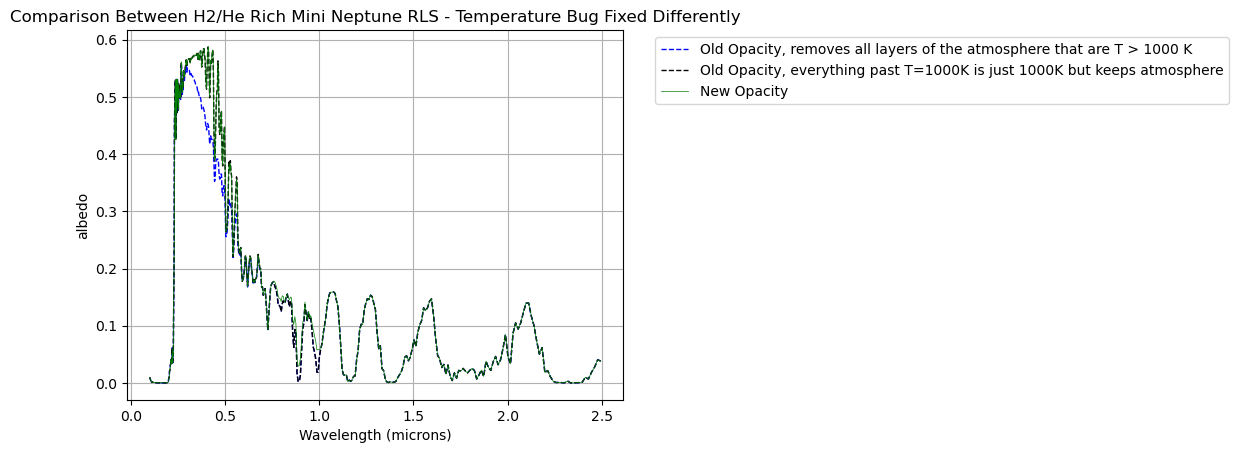

In [21]:
plt.plot(1e4/wno_H2HeRich_MiniNep_R15000_oldtempfix_oldopacities, alb_H2HeRich_MiniNep_R15000_oldtempfix_oldopacities, color='blue', label='Old Opacity, removes all layers of the atmosphere that are T > 1000 K', lw=1, ls='--')
plt.plot(1e4/wno_H2HeRich_MiniNep_R15000_newtempfix_oldopacities, alb_H2HeRich_MiniNep_R15000_newtempfix_oldopacities, color='black', label='Old Opacity, everything past T=1000K is just 1000K but keeps atmosphere', lw=1, ls='--')
plt.plot(1e4/wno_H2HeRich_MiniNep_R15000_newopacities, alb_H2HeRich_MiniNep_R15000_newopacities, color='green', label='New Opacity', lw=0.5)
plt.title("Comparison Between H2/He Rich Mini Neptune RLS - Temperature Bug Fixed Differently")
plt.xlabel("Wavelength (microns)")
plt.ylabel("albedo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

#### Comparison to Archean Earth (also updated wavelength & opacity)

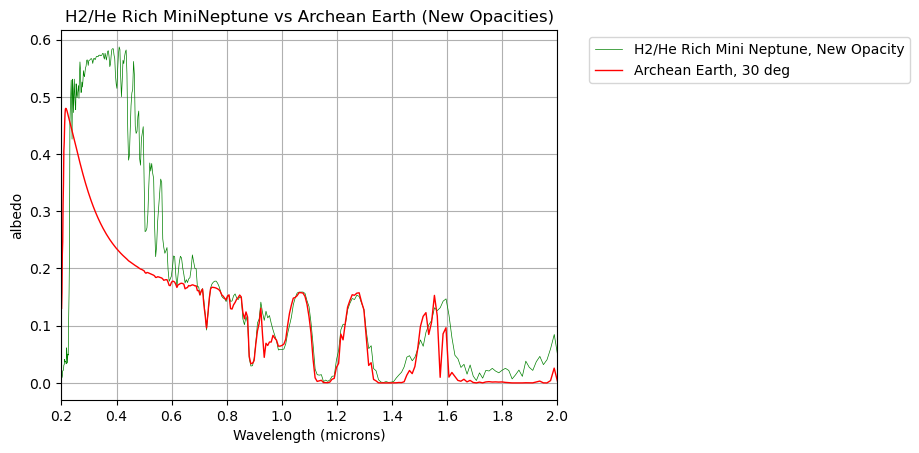

In [16]:
plt.plot(1e4/wno_H2HeRich_MiniNep_R15000_newopacities, alb_H2HeRich_MiniNep_R15000_newopacities, color='green', label='H2/He Rich Mini Neptune, New Opacity', lw=0.5)
plt.plot(1e4/wno_ArcheanEarth_30deg_newopacity, alb_ArcheanEarth_30deg_newopacity, color='red', label='Archean Earth, 30 deg', lw=1)
plt.title("H2/He Rich MiniNeptune vs Archean Earth (New Opacities)")
plt.xlabel("Wavelength (microns)")
plt.ylabel("albedo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0.2,2)
plt.grid(True)
plt.show()

### Case 2

In [3]:
index_list = [7] # This is the index of the above dictionary of 175 Modern Matches of RLS from the Photochem Grid

for index in index_list:

    filename = 'data/grid_results/ReflectedSpectra_SpecificInputsModernEarth_fv.h5'
    
    with h5py.File(filename, 'r') as f:
    
        # Input parameters for every case — shape (N, 7)
        # Columns: [rad, metal, tint, semi_major, ctoO, kzz, phase_angle]
        inputs = np.array(f['inputs'])
    
        # Which cases finished successfully — shape (N,)
        completed = np.array(f['completed'])
    
        # Spectral results — each shape (N, ~150)
        inputs = np.array(f['inputs'])
        wno_list    = np.array(f['results']['wno'])
        fpfs_list   = np.array(f['results']['fpfs'])
        albedo_list = np.array(f['results']['albedo'])
        clouds_list = np.array(f['results']['clouds'])
        status_list = np.array(f['results']['status'])   # byte strings, e.g. b'ok'
    
    wno_O2 = wno_list[int(index)]
    fpfs_O2 = fpfs_list[int(index)]
    alb_O2 = albedo_list[int(index)]
    inputs_list_O2 = inputs[int(index)]

print(inputs_list_O2)

[2.000e+00 3.125e+00 2.000e+02 1.000e+00 1.000e-02 5.000e+00 0.000e+00]


In [4]:
with open('data/RLS_results/RLS_O2_MiniNep_R15000_updatedtempfix_cld0.5.pkl', 'rb') as f:
    O2_MiniNep_R15000_updatedtempfix = pickle.load(f)
    wno_O2_MiniNep_R15000_updatedtempfix = O2_MiniNep_R15000_updatedtempfix['wno']
    alb_O2_MiniNep_R15000_updatedtempfix = O2_MiniNep_R15000_updatedtempfix['alb']

with open('data/RLS_results/RLS_O2_MiniNep_R15000_newopacity_cld0.5.pkl', 'rb') as f:
    O2_MiniNep_R15000_newopacity = pickle.load(f)
    wno_O2_MiniNep_R15000_newopacity = O2_MiniNep_R15000_newopacity['wno']
    alb_O2_MiniNep_R15000_newopacity = O2_MiniNep_R15000_newopacity['alb']

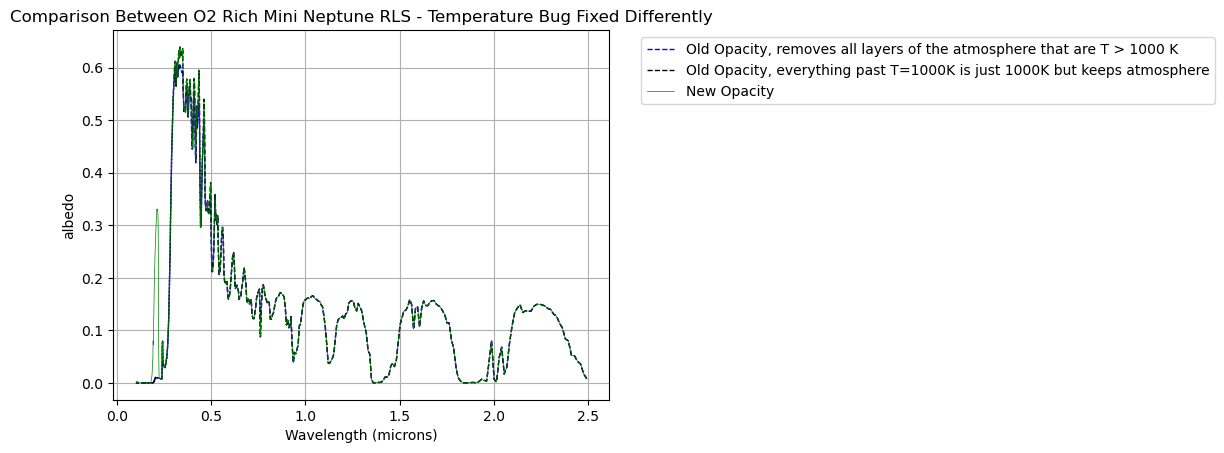

In [5]:
plt.plot(1e4/wno_O2, alb_O2, color='blue', label='Old Opacity, removes all layers of the atmosphere that are T > 1000 K', lw=1, ls='--')
plt.plot(1e4/wno_O2_MiniNep_R15000_updatedtempfix, alb_O2_MiniNep_R15000_updatedtempfix, color='black', label='Old Opacity, everything past T=1000K is just 1000K but keeps atmosphere', lw=1, ls='--')
plt.plot(1e4/wno_O2_MiniNep_R15000_newopacity, alb_O2_MiniNep_R15000_newopacity, color='green', label='New Opacity', lw=0.5)
plt.title("Comparison Between O2 Rich Mini Neptune RLS - Temperature Bug Fixed Differently")
plt.xlabel("Wavelength (microns)")
plt.ylabel("albedo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Case 3

In [7]:
index_list_archean = [5026]

for index in index_list_archean:

    filename = 'data/grid_results/ReflectedSpectra_SpecificInputsArcheanEarth_try2_fv.h5'
    
    with h5py.File(filename, 'r') as f:
    
        # Input parameters for every case — shape (N, 7)
        # Columns: [rad, metal, tint, semi_major, ctoO, kzz, phase_angle]
        inputs_archeanmatch = np.array(f['inputs'])
    
        # Which cases finished successfully — shape (N,)
        completed = np.array(f['completed'])
    
        # Spectral results — each shape (N, ~150)
        wno_archeanmatch = np.array(f['results']['wno'])
        fpfs_archeanmatch = np.array(f['results']['fpfs'])
        albedo_archeanmatch = np.array(f['results']['albedo'])
        clouds_archeanmatch = np.array(f['results']['clouds'])
        status_archeanmatch = np.array(f['results']['status'])   # byte strings, e.g. b'ok'

        print(f['results'].keys())
    
    
    wno_CORich = wno_archeanmatch[index]
    fpfs_CORich = fpfs_archeanmatch[index]
    alb_CORich = albedo_archeanmatch[index]
    inputs_list_CORich = inputs_archeanmatch[index]

<KeysViewHDF5 ['albedo', 'clouds', 'fpfs', 'status', 'wno']>


In [8]:
with open('data/RLS_results/RLS_H2CORich_MiniNep_R15000_updatedtempfix_cld0.5.pkl', 'rb') as f:
    H2CORich_MiniNep_R15000_updatedtempfix = pickle.load(f)
    wno_H2CORich_MiniNep_R15000_updatedtempfix = H2CORich_MiniNep_R15000_updatedtempfix['wno']
    alb_H2CORich_MiniNep_R15000_updatedtempfix = H2CORich_MiniNep_R15000_updatedtempfix['alb']

with open('data/RLS_results/RLS_H2CORich_MiniNep_R15000_newopacity_cld0.5.pkl', 'rb') as f:
    H2CO_MiniNep_R15000_newopacity = pickle.load(f)
    wno_H2CO_MiniNep_R15000_newopacity = H2CO_MiniNep_R15000_newopacity['wno']
    alb_H2CO_MiniNep_R15000_newopacity = H2CO_MiniNep_R15000_newopacity['alb']

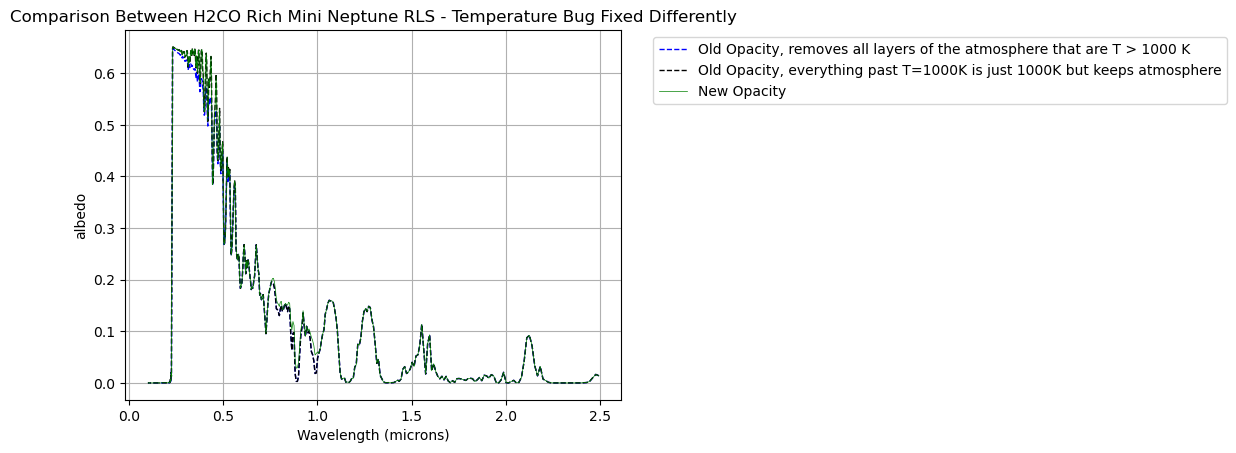

In [9]:
plt.plot(1e4/wno_CORich, alb_CORich, color='blue', label='Old Opacity, removes all layers of the atmosphere that are T > 1000 K', lw=1, ls='--')
plt.plot(1e4/wno_H2CORich_MiniNep_R15000_updatedtempfix, alb_H2CORich_MiniNep_R15000_updatedtempfix, color='black', label='Old Opacity, everything past T=1000K is just 1000K but keeps atmosphere', lw=1, ls='--')
plt.plot(1e4/wno_H2CO_MiniNep_R15000_newopacity, alb_H2CO_MiniNep_R15000_newopacity, color='green', label='New Opacity', lw=0.5)
plt.title("Comparison Between H2CO Rich Mini Neptune RLS - Temperature Bug Fixed Differently")
plt.xlabel("Wavelength (microns)")
plt.ylabel("albedo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## Determine Issue with Cloud Thickness Calculation & Plot

In [25]:
### More Typical Mini-Neptune Case (H-He Rich)

with open('individual_rerun_data/grid_results/PhotochemPT_MiniNep_2.0_2.0_50.0_1.0_0.7525_5.0.pkl', 'rb') as f:
    H2HeRich_photochem_data = pickle.load(f)
    print(H2HeRich_photochem_data.keys())
    sol_H2HeRich = H2HeRich_photochem_data['sol_dict']
    soleq_H2HeRich = H2HeRich_photochem_data['soleq_dict']
    temp_H2HeRich = H2HeRich_photochem_data['temperature']
    pres_H2HeRich = H2HeRich_photochem_data['pressure']

    top_keys, molecule_means = get_top_molecules_for_case(photochem_data=H2HeRich_photochem_data, top_n=12)
    print(len(top_keys))
    print(top_keys)
    print(sol_H2HeRich.keys())

dict_keys(['sol_dict', 'soleq_dict', 'pressure', 'temperature'])
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]
12
['H2', 'He', 'H', 'CO', 'CO2', 'C2H2', 'CH4', 'N2', 'H2O', 'C4H2', 'C2H6', 'C2H4']
dict_keys(['1CH2', 'C2H2OH', 'C2H2', 'C2H2aer', 'C2H3OH', 'C2H3', 'C2H4OH', 'C2H4', 'C2H4aer', 'C2H5', 'C2H6', 'C2H6aer', 'C2H', 'C2', 'C3H4', 'C3H6', 'C4H2', 'C4H3', 'C4H4', 'C4H', 'CH2CHO', 'CH2CN', 'CH2CO', 'CH2N2', 'CH2', 'CH3CHO', 'CH

dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])
0.040358904929349376 0.034593347082299455


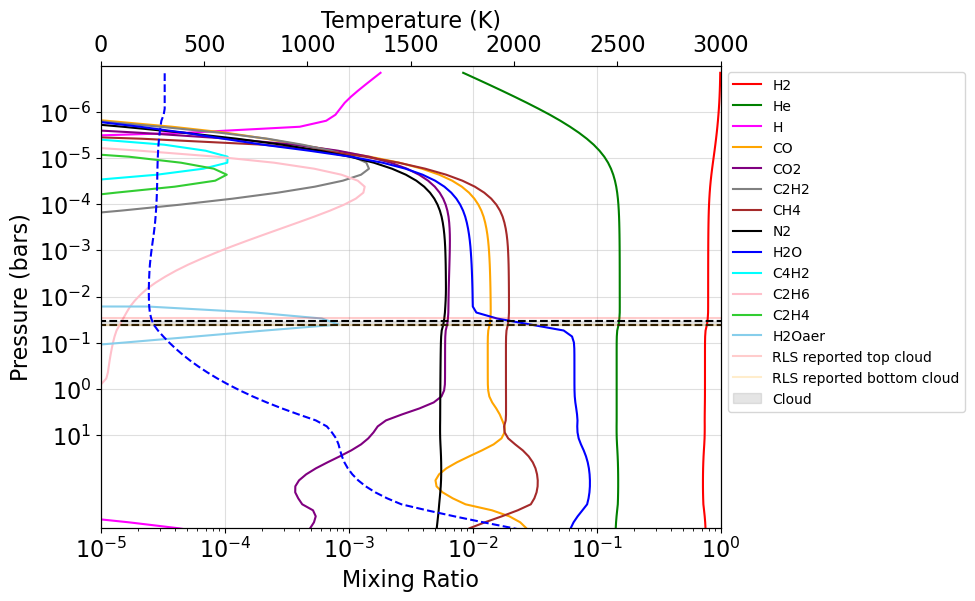

In [49]:
#### Figure 1:
plot_photochem_model_with_cloud(sol=sol_H2HeRich, soleq=soleq_H2HeRich)

In [28]:
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_cld0.5.pkl', 'rb') as f:
    H2HeRich_MiniNep_R15000_oldtempfix_oldopacities = pickle.load(f)
    wno_H2HeRich_MiniNep_R15000_oldtempfix_oldopacities = H2HeRich_MiniNep_R15000_oldtempfix_oldopacities['wno']
    alb_H2HeRich_MiniNep_R15000_oldtempfix_oldopacities = H2HeRich_MiniNep_R15000_oldtempfix_oldopacities['alb']

    full_output = H2HeRich_MiniNep_R15000_oldtempfix_oldopacities['df_cld']['full_output']

# Note the following cloud method cannot be used if the cloud is smaller than the binning used in PICASO -- which in this case it is.

In [43]:
# Extract cloud properties
opd_per_layer = full_output['layer']['cloud']['opd']   # shape (nlayers, nwavenumbers)
pressure_levels = full_output['level']['pressure']      # N+1 interface pressures

# Per-layer threshold to exclude ghost cloud (opd=1e-4)
per_layer_threshold = 1e-3

# --- Single wavelength ---
wavelength_idx = 0
cloud_opd_spectrum = opd_per_layer[:, wavelength_idx]
real_cloud_indices = np.where(cloud_opd_spectrum > per_layer_threshold)[0]

if len(real_cloud_indices) > 0:
    cloud_top_index = real_cloud_indices[0]
    cloud_bottom_index = real_cloud_indices[-1]
    cloud_top_pressure = pressure_levels[cloud_top_index]
    cloud_bottom_pressure = pressure_levels[cloud_bottom_index + 1]
    cloud_thickness_pressure = cloud_bottom_pressure - cloud_top_pressure
    total_cloud_opd = np.sum(cloud_opd_spectrum)

    print(f"Cloud top pressure: {cloud_top_pressure:.4f} bars")
    print(f"Cloud bottom pressure: {cloud_bottom_pressure:.4f} bars")
    print(f"Cloud thickness: {cloud_thickness_pressure:.4f} bars")
    print(f"Total cloud optical depth: {total_cloud_opd:.4f}")
else:
    print("No significant cloud optical depth found at this wavelength")

# --- All wavelengths ---
cloud_tops = []
cloud_bottoms = []
cloud_thicknesses = []

for wno_idx in range(opd_per_layer.shape[1]):
    cloud_opd = opd_per_layer[:, wno_idx]
    real_cloud_indices = np.where(cloud_opd > per_layer_threshold)[0]

    if len(real_cloud_indices) > 0:
        top_pressure = pressure_levels[real_cloud_indices[0]]
        bottom_pressure = pressure_levels[real_cloud_indices[-1] + 1]
        cloud_tops.append(top_pressure)
        cloud_bottoms.append(bottom_pressure)
        cloud_thicknesses.append(bottom_pressure - top_pressure)
    else:
        cloud_tops.append(np.nan)
        cloud_bottoms.append(np.nan)
        cloud_thicknesses.append(0)

cloud_tops = np.array(cloud_tops)
cloud_bottoms = np.array(cloud_bottoms)
cloud_thicknesses = np.array(cloud_thicknesses)

print(f"Cloud top pressures shape: {cloud_tops.shape}")
print(f"Mean cloud top pressure: {np.nanmean(cloud_tops):.4f} bars")
print(f"Mean cloud bottom pressure: {np.nanmean(cloud_bottoms):.4f} bars")
print(f"Mean cloud thickness: {np.nanmean(cloud_thicknesses):.4f} bars")


Cloud top pressure: 0.0299 bars
Cloud bottom pressure: 0.0404 bars
Cloud thickness: 0.0104 bars
Total cloud optical depth: 10.0000
Cloud top pressures shape: (48771,)
Mean cloud top pressure: 0.0299 bars
Mean cloud bottom pressure: 0.0404 bars
Mean cloud thickness: 0.0104 bars
